In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

import random
import numpy as np
import pandas as pd
import seaborn as sns
from pprint import pprint
from pathlib import Path
from matplotlib import pyplot as plt

import torch
from torchinfo import summary
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

from modules.datamodule import LungSoundDataModule
from modules.classifier import LungSoundClassifier
from modules.transforms import *

W0616 17:00:36.504000 24112 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [2]:
PROJECT_ROOT = Path(os.path.dirname(os.getcwd()))
DATA_FOLDER = PROJECT_ROOT / "data" / "preprocessed"
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

LOGS_FOLDER = PROJECT_ROOT / "logs"
if not os.path.exists(LOGS_FOLDER):
    os.makedirs(LOGS_FOLDER)

CHECKPOINTS_FOLDER = PROJECT_ROOT / "checkpoints"
if not os.path.exists(CHECKPOINTS_FOLDER):
    os.makedirs(CHECKPOINTS_FOLDER)

RESULTS_FOLDER = PROJECT_ROOT / "results"
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

torch.set_float32_matmul_precision("high")
%load_ext tensorboard

Using device: cuda


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_input_size(dm: LungSoundDataModule) -> tuple:
    """
    Get the input size for the model based on a sample batch from the DataModule.
    Args:
        dm (LungSoundDataModule): The DataModule to sample from.
    Returns:
        input_size (tuple): Tuple representing the shape of the input data (e.g., (B, C, H, W)).
    """
    dm.setup()
    loader = dm.train_dataloader()
    batch = next(iter(loader))
    inputs, _, _ = batch
    return tuple(inputs.shape)


def save_results(model) -> None:
    """
    Save test results to a CSV file.
    Args:
        test_results (dict): Dictionary containing test metrics and results.
        path (Path | str): Path to the CSV file where results will be saved.
    """
    classes = model.hparams.dataset["classes"]
    probs_df = pd.DataFrame(model.test_results["probs"], columns=[f"prob_{cls}" for cls in classes])
    results_df = pd.DataFrame({
        "target": model.test_results["targets"],
        "pred": model.test_results["preds"],
    })
    info_df = pd.DataFrame(model.test_results["info"])
    results_df = pd.concat([results_df, probs_df, info_df], axis=1)
    path = RESULTS_FOLDER / f"{model.hparams['experiment']}_results.csv"
    results_df.to_csv(path, index=False)
    print(f"Test results saved to {path}")


def train_model(hparams: dict, debug: bool = False) -> LungSoundClassifier:
    """
    Train a model.
    Args:
        hparams (dict): Hyperparameters and configuration for the experiment. Trainer parameters:
        ```
        - experiment (str): Name of the experiment for logging and checkpointing.
        - checkpoint_monitor (str): Metric to monitor for checkpointing (e.g., "val_loss").
        - checkpoint_mode (str): Mode for checkpointing ("min" or "max").
        - early_stop_monitor (str): Metric to monitor for early stopping (e.g., "val_loss").
        - early_stop_mode (str): Mode for early stopping ("min" or "max").
        - patience (int): Number of epochs with no improvement after which training will be stopped.
        - max_epochs (int): Maximum number of training epochs.
        - precision (int): Precision for training (e.g., 16 for mixed precision).
        ```
        debug (bool): If True, dry run the training for quick debugging. Default is False.
    Returns:
        model (LungSoundClassifier): The trained model.
    """
    set_seed(hparams["seed"])

    # Display experiment hyperparameters
    print("Experiment hyperparameters:")
    pprint(hparams)

    # Initialize logger
    logger = TensorBoardLogger(
        save_dir=LOGS_FOLDER,
        name=hparams["experiment"],
    )

    # Initialize callbacks
    callbacks = []
    if not debug:
        checkpoint_callback = ModelCheckpoint(
            dirpath=CHECKPOINTS_FOLDER,
            filename=hparams["experiment"] + "-{epoch}-{val_loss:.2f}-{val_f1_micro:.2f}-{val_f1_macro:.2f}",
            monitor=hparams["checkpoint_monitor"],
            mode=hparams["checkpoint_mode"],
            save_top_k=1,
            verbose=True,
        )
        callbacks.append(checkpoint_callback)

        early_stopping_callback = EarlyStopping(
            monitor=hparams["early_stop_monitor"],
            mode=hparams["early_stop_mode"],
            patience=hparams["patience"],
            verbose=True,
        )
        callbacks.append(early_stopping_callback)

    # Initialize DataModule and Model
    dm = LungSoundDataModule(hparams, DATA_FOLDER)
    model = LungSoundClassifier(hparams)

    # Display model architecture
    input_shape = get_input_size(dm)
    print("Model Summary:\n")
    print(f"Input shape: {input_shape}")
    print(summary(model, input_size=input_shape))
    print("\n")

    # Initialize Trainer
    trainer = Trainer(
        accelerator="gpu" if DEVICE == "cuda" else "cpu",
        devices="auto",
        max_epochs=hparams["max_epochs"],
        precision=hparams["precision"],
        callbacks=callbacks,
        logger=logger,
        fast_dev_run=debug,
    )

    # Train the model
    trainer.fit(model, dm)

    # Test the model
    trainer.test(model, dm)

    # Save test results to a CSV
    save_results(model)

    return model

In [4]:
def show_metrics(targets: np.ndarray, preds: np.ndarray, probs: np.ndarray, class_names: list):
    """
    Display classification metrics including classification report, ROC AUC curve, Precision-Recall curve, and confusion matrix.
    Args:
        targets (np.ndarray): Array of true target labels.
        preds (np.ndarray): Array of predicted labels by the model.
        probs (np.ndarray): Array of predicted probabilities for each class.
        class_names (list): List of class names corresponding to the target labels.
    """
    # y_true in one-hot encoding format for multi-class metrics
    y_true = label_binarize(targets, classes=np.arange(len(class_names)))

    # Print classification report
    print("Classification Report:")
    print(classification_report(targets, preds, target_names=class_names))

    # Plot ROC curves
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, class_name in enumerate(class_names):
        RocCurveDisplay.from_predictions(y_true[:, i], probs[:, i], name=class_name, ax=ax)
    ax.set_title("ROC Curves")
    plt.show()

    # Plot Precision-Recall curves
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, class_name in enumerate(class_names):
        PrecisionRecallDisplay.from_predictions(y_true[:, i], probs[:, i], name=class_name, ax=ax)
    ax.set_title("Precision-Recall Curves")
    plt.show()

    # Plot confusion matrix
    cm = confusion_matrix(targets, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    plt.title("Confusion Matrix")
    plt.show()


def evaluate_model(model: LungSoundClassifier, test_model: bool = False):
    """
    Evaluate the model on the test set and display metrics.
    Args:
        model (LungSoundClassifier): The trained model to evaluate.
        test_model (bool): If True, run the test loop to populate test results.
    """
    hparams = model.hparams
    if not hasattr(model, "test_results") or test_model:
        dm = LungSoundDataModule(model.hparams, DATA_FOLDER)
        trainer = Trainer(
            accelerator="gpu" if DEVICE == "cuda" else "cpu",
            devices="auto",
            precision=model.hparams["precision"],
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
            enable_model_summary=False,
        )
        trainer.test(model, dm)

    targets = np.asarray(model.test_results["targets"])
    preds = np.asarray(model.test_results["preds"])
    probs = np.asarray(model.test_results["probs"])
    class_names = hparams.dataset["classes"]
    show_metrics(targets, preds, probs, class_names)

## Experiments with ResNet50

In [5]:
hparams = {
    "experiment": "",               # This will be modified for each experiment

    # Callbacks
    "checkpoint_monitor": "val_f1_macro",
    "checkpoint_mode": "max",
    "early_stop_monitor": "val_f1_macro",
    "early_stop_mode": "max",
    "patience": 10,

    # Training
    "max_epochs": 100,
    "precision": "16-mixed",
    "seed": 42,

    # DataModule
    "batch_size": 16,               # TODO: Adjust batch size based on GPU memory
    "num_workers": 2,               # TODO: Adjust number of workers based on CPU cores
    "sampler": "equalizer",

    # Dataset
    "dataset": {
        "name": "Combined_ICBHI_KAUH",
        "classes": [
            "Asthma",
            "Bronchiectasis",
            "Bronchiolitis",
            "COPD",
            "Healthy",
            "Lung Fibrosis",
            "Pneumonia",
            "URTI",
        ],
        "feature_extractor": "",    # This will be modified for each experiment
        "sample_limit": 1000,
        "transforms": None,
    },

    # Model
    "model": {
        "name": "resnet50",
        "pretrained": None,
        "freeze_layers": False,
    },

    # Optimization
    "criterion": "CrossEntropyLoss",
    "optimizer": "AdamW",
    "learning_rate": 0.0001,
    "weight_decay": 0.00001,
    "momentum": None,
    "lr_scheduler": "StepLR",
    "step_size": 7,
    "gamma": 0.1,
}

### MagSTFT

In [6]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-MagSTFT"
hparams["dataset"]["feature_extractor"] = "MagSTFT"
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'MagSTFT',
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-MagSTFT',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'resnet50', 'pretrained': None},
 'momentum': None,
 'num_workers': 2,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 513, 108]        3,136
│    └─BatchNorm2d: 2-2                       [16, 64, 513, 108]        128
│    └─ReLU: 2-3                              [16, 64, 513, 108]        --
│    └─MaxPool2d: 2-4                         [16, 64, 257, 54]         --
│    └─Sequential: 2-5                        [16, 256, 257, 54]        --
│    │    └─Bottleneck: 3-1                   [16, 256, 257, 54]        75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 257, 54]        70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 257, 54]        70,400
│    └─Sequential: 2-6                        [16, 512, 129, 27]        --
│    │    └─Bottleneck: 3-4                   [16, 512, 129, 27]        379,392

c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | train | 0    
1  | criterion         | CrossEntropyLoss  | 0      | train | 0    
2  | train_f1_macro    | MulticlassF1Score | 0      | train | 0    
3  | train_f1_micro    | MulticlassF1Score | 0      | train | 0    
4  | train_f1_weighted | MulticlassF1Score | 0      | train | 0    
5  | val_f1_macro      | Mul

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.398. Signaling Trainer to stop.
Epoch 26, global step 4104: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 5. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1         0.4871794879436493
 test_Bronchiectasis_f1             1.0
  test_Bronchiolitis_f1     0.13333334028720856
      test_COPD_f1          0.9126213788986206
     test_Healthy_f1        0.6976743936538696
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1        0.746268630027771
      test_URTI_f1                0.3125
      test_f1_macro         0.5361971855163574
      test_f1_micro         0.7169230580329895
    test_f1_weighted        0.6868714094161987
        test_loss            1.062501072883606
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_Sofia\IA901_Pro

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.79      0.35      0.49        54
Bronchiectasis       1.00      1.00      1.00        14
 Bronchiolitis       1.00      0.07      0.13        14
          COPD       0.89      0.94      0.91       100
       Healthy       0.58      0.88      0.70        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.78      0.71      0.75        35
          URTI       0.28      0.36      0.31        14

      accuracy                           0.72       325
     macro avg       0.66      0.54      0.54       325
  weighted avg       0.74      0.72      0.69       325



c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

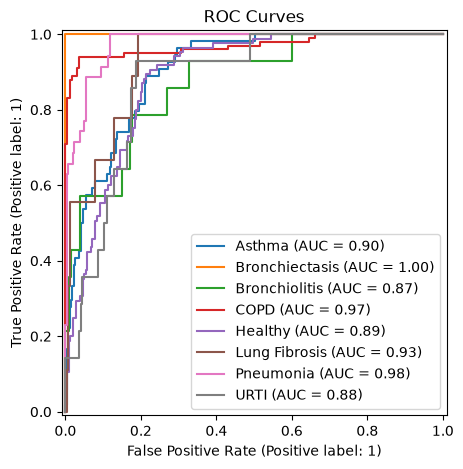

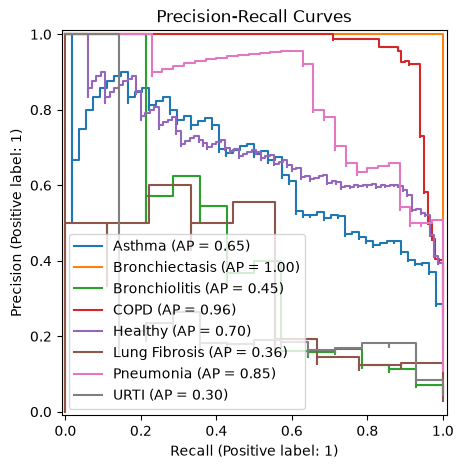

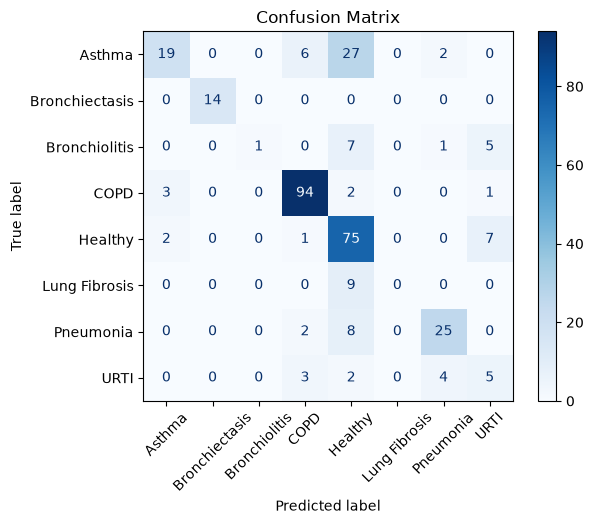

In [7]:
evaluate_model(model)

### MelSpectrogram

In [8]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-MelSpectrogram"
hparams["dataset"]["feature_extractor"] = "MelSpectrogram"
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'MelSpectrogram',
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-MelSpectrogram',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'resnet50', 'pretrained': None},
 'momentum': None,
 'num_workers': 2,
 'optimizer': 'AdamW',
 'patience': 1

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Model Summary:

Input shape: (16, 1, 128, 216)
Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 64, 108]         3,136
│    └─BatchNorm2d: 2-2                       [16, 64, 64, 108]         128
│    └─ReLU: 2-3                              [16, 64, 64, 108]         --
│    └─MaxPool2d: 2-4                         [16, 64, 32, 54]          --
│    └─Sequential: 2-5                        [16, 256, 32, 54]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 32, 54]         75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 32, 54]         70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 32, 54]         70,400
│    └─Sequential: 2-6                        [16, 512, 16, 27]         --
│    │    └─Bottleneck: 3-4     

c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | train | 0    
1  | criterion         | CrossEntropyLoss  | 0      | train | 0    
2  | train_f1_macro    | MulticlassF1Score | 0      | train | 0    
3  | train_f1_micro    | MulticlassF1Score | 0      | train | 0    
4  | train_f1_weighted | MulticlassF1Score | 0      | train | 0    
5  | val_f1_macro      | MulticlassF1Score | 0      | train | 0    
6  | val_f1_micro      | MulticlassF1Score | 0      | train | 0    
7  | val_f1_weighted   | MulticlassF1Score | 0      | train | 0    
8  | test_f1_macro     | MulticlassF1Score | 0      | train | 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 11, global step 1824: 'val_f1_macro' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.364. Signaling Trainer to stop.
Epoch 12, global step 1976: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1          0.650602400302887
 test_Bronchiectasis_f1     0.7272727489471436
  test_Bronchiolitis_f1     0.3636363744735718
      test_COPD_f1          0.8682926893234253
     test_Healthy_f1        0.6764705777168274
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1       0.7878788113594055
      test_URTI_f1          0.25641027092933655
      test_f1_macro         0.5413204431533813
      test_f1_micro         0.7015384435653687
    test_f1_weighted        0.6950770616531372
        test_loss           1.1937445402145386
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_So

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.93      0.50      0.65        54
Bronchiectasis       1.00      0.57      0.73        14
 Bronchiolitis       0.50      0.29      0.36        14
          COPD       0.85      0.89      0.87       100
       Healthy       0.58      0.81      0.68        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.84      0.74      0.79        35
          URTI       0.20      0.36      0.26        14

      accuracy                           0.70       325
     macro avg       0.61      0.52      0.54       325
  weighted avg       0.73      0.70      0.70       325



c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

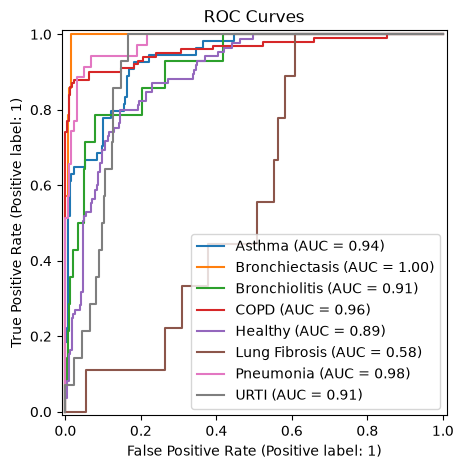

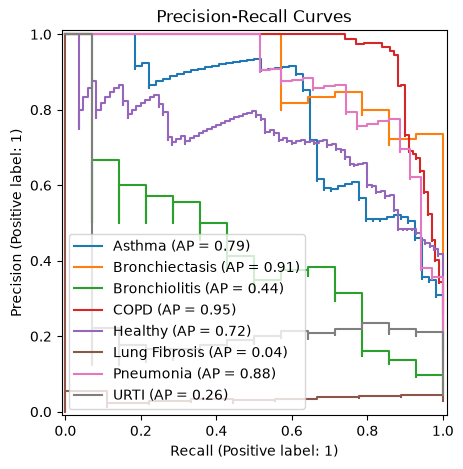

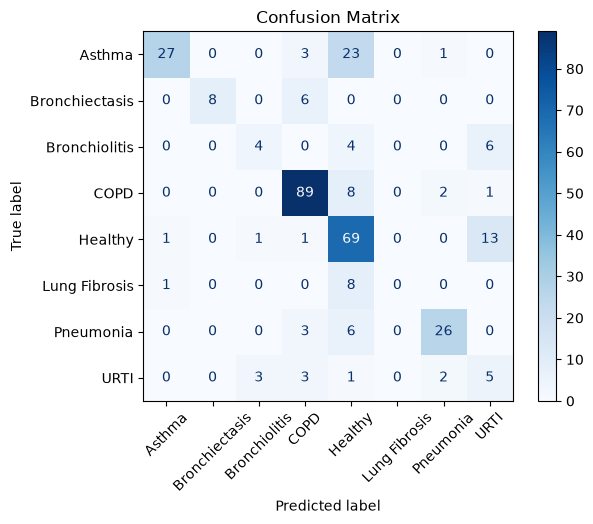

In [9]:
evaluate_model(model)

### MFCC

In [10]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-MFCC"
hparams["dataset"]["feature_extractor"] = "MFCC"
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'MFCC',
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-MFCC',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'resnet50', 'pretrained': None},
 'momentum': None,
 'num_workers': 2,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision': '16

Using 16bit Automatic Mixed Precision (AMP)


Model Summary:

Input shape: (16, 1, 128, 216)
Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 64, 108]         3,136
│    └─BatchNorm2d: 2-2                       [16, 64, 64, 108]         128
│    └─ReLU: 2-3                              [16, 64, 64, 108]         --
│    └─MaxPool2d: 2-4                         [16, 64, 32, 54]          --
│    └─Sequential: 2-5                        [16, 256, 32, 54]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 32, 54]         75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 32, 54]         70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 32, 54]         70,400
│    └─Sequential: 2-6                        [16, 512, 16, 27]         --
│    │    └─Bottleneck: 3-4     

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | trai

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 10, global step 1672: 'val_f1_macro' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.304. Signaling Trainer to stop.
Epoch 11, global step 1824: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1         0.5316455960273743
 test_Bronchiectasis_f1     0.9230769276618958
  test_Bronchiolitis_f1            0.125
      test_COPD_f1          0.8878048658370972
     test_Healthy_f1        0.6696428656578064
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1       0.49180328845977783
      test_URTI_f1          0.23076923191547394
      test_f1_macro         0.4824678301811218
      test_f1_micro          0.670769214630127
    test_f1_weighted        0.6446952819824219
        test_loss            1.386117935180664
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_Sofia\I

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.84      0.39      0.53        54
Bronchiectasis       1.00      0.86      0.92        14
 Bronchiolitis       0.50      0.07      0.12        14
          COPD       0.87      0.91      0.89       100
       Healthy       0.54      0.88      0.67        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.58      0.43      0.49        35
          URTI       0.25      0.21      0.23        14

      accuracy                           0.67       325
     macro avg       0.57      0.47      0.48       325
  weighted avg       0.68      0.67      0.64       325



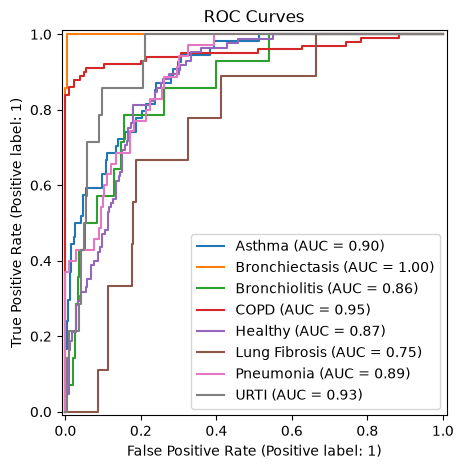

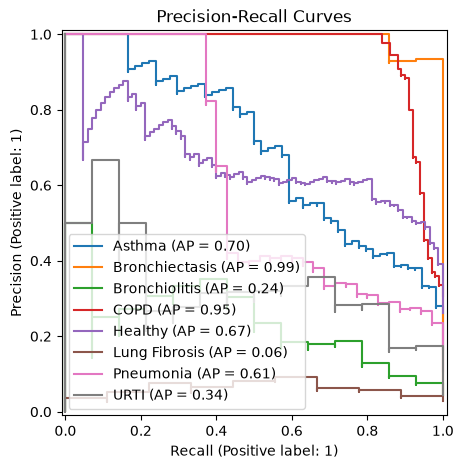

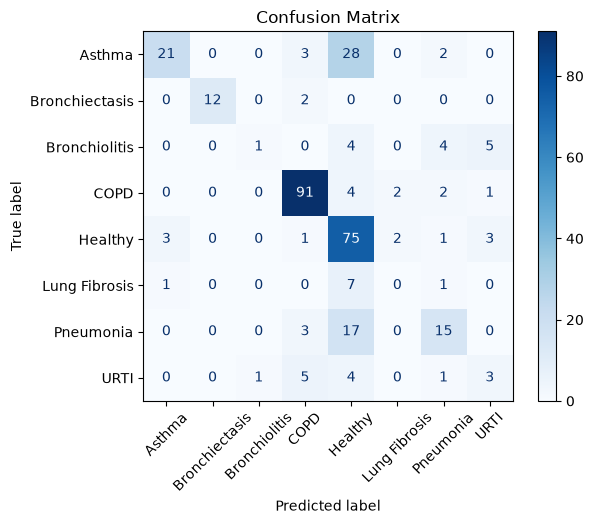

In [11]:
evaluate_model(model)

### MFCCDelta

In [12]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-MFCCDelta"
hparams["dataset"]["feature_extractor"] = "MFCCDelta"
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'MFCCDelta',
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-MFCCDelta',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'resnet50', 'pretrained': None},
 'momentum': None,
 'num_workers': 2,
 'optimizer': 'AdamW',
 'patience': 10,
 'preci

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Model Summary:

Input shape: (16, 1, 128, 216)
Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 64, 108]         3,136
│    └─BatchNorm2d: 2-2                       [16, 64, 64, 108]         128
│    └─ReLU: 2-3                              [16, 64, 64, 108]         --
│    └─MaxPool2d: 2-4                         [16, 64, 32, 54]          --
│    └─Sequential: 2-5                        [16, 256, 32, 54]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 32, 54]         75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 32, 54]         70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 32, 54]         70,400
│    └─Sequential: 2-6                        [16, 512, 16, 27]         --
│    │    └─Bottleneck: 3-4     

c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | train | 0    
1  | criterion         | CrossEntropyLoss  | 0      | train | 0    
2  | train_f1_macro    | MulticlassF1Score | 0      | train | 0    
3  | train_f1_micro    | MulticlassF1Score | 0      | train | 0    
4  | train_f1_weighted | MulticlassF1Score | 0      | train | 0    
5  | val_f1_macro      | Mul

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 17, global step 2736: 'val_f1_macro' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.189. Signaling Trainer to stop.
Epoch 18, global step 2888: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1         0.5822784900665283
 test_Bronchiectasis_f1     0.20000000298023224
  test_Bronchiolitis_f1     0.37037035822868347
      test_COPD_f1          0.7864077687263489
     test_Healthy_f1        0.5872340202331543
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1       0.07999999821186066
      test_URTI_f1                  0.0
      test_f1_macro         0.3257863223552704
      test_f1_micro         0.5600000023841858
    test_f1_weighted        0.5254889130592346
        test_loss           1.8618220090866089
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_Sofia\I

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.92      0.43      0.58        54
Bronchiectasis       0.33      0.14      0.20        14
 Bronchiolitis       0.38      0.36      0.37        14
          COPD       0.76      0.81      0.79       100
       Healthy       0.46      0.81      0.59        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.13      0.06      0.08        35
          URTI       0.00      0.00      0.00        14

      accuracy                           0.56       325
     macro avg       0.37      0.33      0.33       325
  weighted avg       0.55      0.56      0.53       325



c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

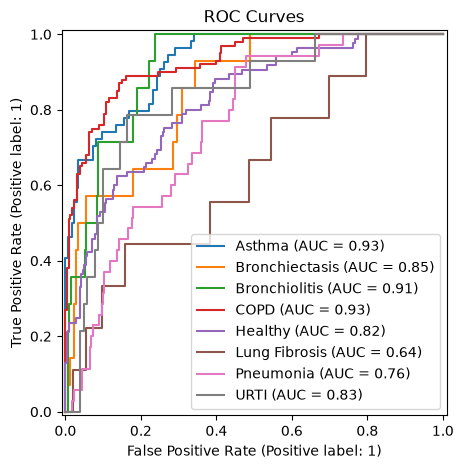

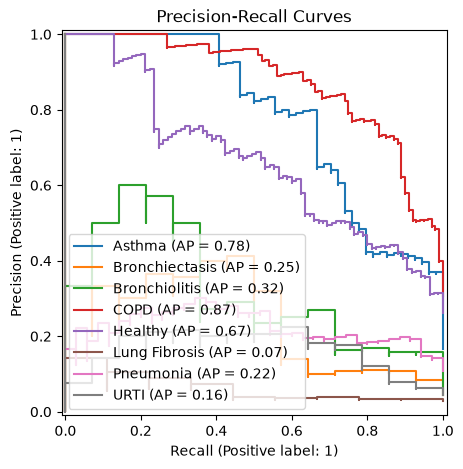

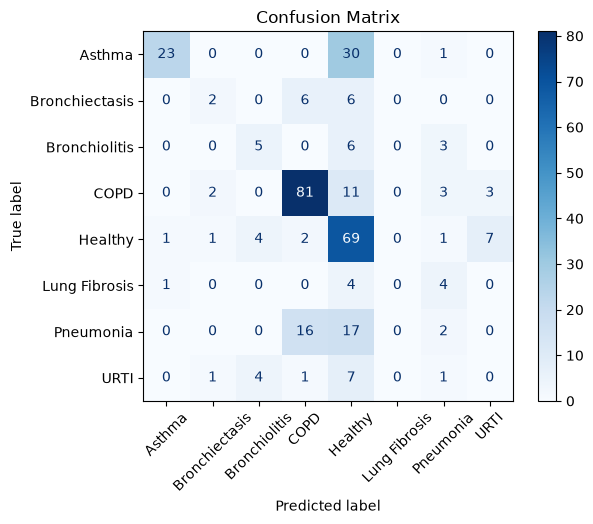

In [13]:
evaluate_model(model)

### Chroma

In [14]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-Chroma"
hparams["dataset"]["feature_extractor"] = "Chroma"
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'Chroma',
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-Chroma',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'resnet50', 'pretrained': None},
 'momentum': None,
 'num_workers': 2,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision':

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Model Summary:

Input shape: (16, 1, 128, 216)
Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 64, 108]         3,136
│    └─BatchNorm2d: 2-2                       [16, 64, 64, 108]         128
│    └─ReLU: 2-3                              [16, 64, 64, 108]         --
│    └─MaxPool2d: 2-4                         [16, 64, 32, 54]          --
│    └─Sequential: 2-5                        [16, 256, 32, 54]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 32, 54]         75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 32, 54]         70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 32, 54]         70,400
│    └─Sequential: 2-6                        [16, 512, 16, 27]         --
│    │    └─Bottleneck: 3-4     

c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | train | 0    
1  | criterion         | CrossEntropyLoss  | 0      | train | 0    
2  | train_f1_macro    | MulticlassF1Score | 0      | train | 0    
3  | train_f1_micro    | MulticlassF1Score | 0      | train | 0    
4  | train_f1_weighted | MulticlassF1Score | 0      | train | 0    
5  | val_f1_macro      | Mul

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 14, global step 2280: 'val_f1_macro' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.236. Signaling Trainer to stop.
Epoch 15, global step 2432: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1         0.5050504803657532
 test_Bronchiectasis_f1     0.10000000149011612
  test_Bronchiolitis_f1             0.0
      test_COPD_f1          0.6530612111091614
     test_Healthy_f1        0.4672897160053253
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1      0.056338027119636536
      test_URTI_f1          0.07999999821186066
      test_f1_macro         0.23271743953227997
      test_f1_micro         0.4399999976158142
    test_f1_weighted        0.42089325189590454
        test_loss           2.3491997718811035
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_Sofia

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.56      0.46      0.51        54
Bronchiectasis       0.17      0.07      0.10        14
 Bronchiolitis       0.00      0.00      0.00        14
          COPD       0.67      0.64      0.65       100
       Healthy       0.39      0.59      0.47        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.06      0.06      0.06        35
          URTI       0.09      0.07      0.08        14

      accuracy                           0.44       325
     macro avg       0.24      0.24      0.23       325
  weighted avg       0.42      0.44      0.42       325



c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

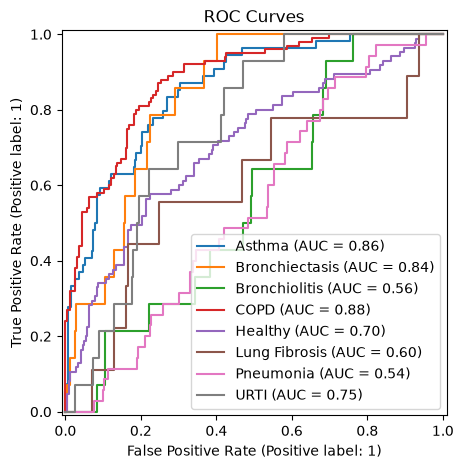

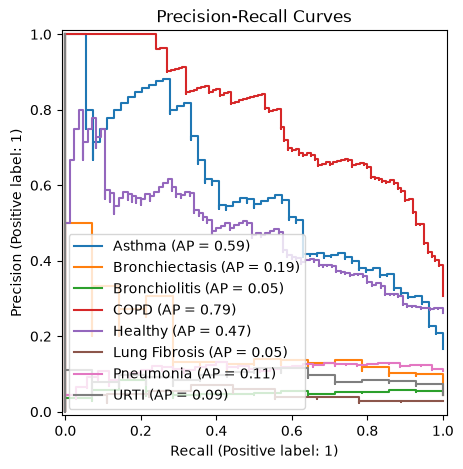

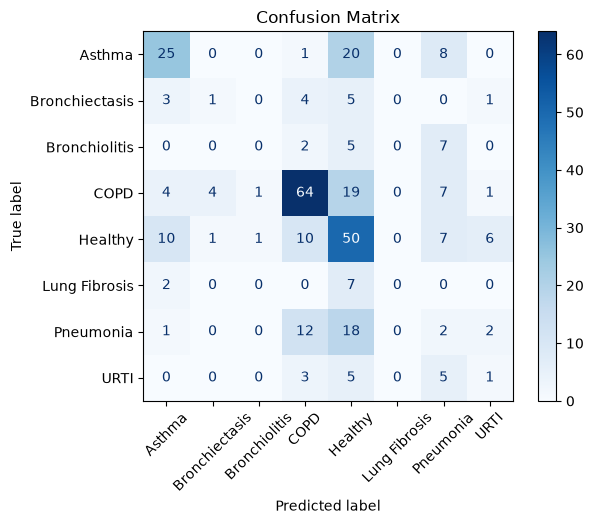

In [15]:
evaluate_model(model)

### Phase

In [16]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-Phase"
hparams["dataset"]["feature_extractor"] = "Phase"
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': 'Phase',
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-Phase',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'resnet50', 'pretrained': None},
 'momentum': None,
 'num_workers': 2,
 'optimizer': 'AdamW',
 'patience': 10,
 'precision': '

Using 16bit Automatic Mixed Precision (AMP)


Model Summary:

Input shape: (16, 1, 1025, 216)
Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 513, 108]        3,136
│    └─BatchNorm2d: 2-2                       [16, 64, 513, 108]        128
│    └─ReLU: 2-3                              [16, 64, 513, 108]        --
│    └─MaxPool2d: 2-4                         [16, 64, 257, 54]         --
│    └─Sequential: 2-5                        [16, 256, 257, 54]        --
│    │    └─Bottleneck: 3-1                   [16, 256, 257, 54]        75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 257, 54]        70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 257, 54]        70,400
│    └─Sequential: 2-6                        [16, 512, 129, 27]        --
│    │    └─Bottleneck: 3-4    

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | trai

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 14, global step 2280: 'val_f1_macro' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.127. Signaling Trainer to stop.
Epoch 15, global step 2432: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1         0.2222222238779068
 test_Bronchiectasis_f1             0.0
  test_Bronchiolitis_f1             0.0
      test_COPD_f1          0.49438202381134033
     test_Healthy_f1        0.3141361176967621
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1       0.13953489065170288
      test_URTI_f1          0.1111111119389534
      test_f1_macro         0.16017329692840576
      test_f1_micro         0.3384615480899811
    test_f1_weighted        0.2910124659538269
        test_loss           2.4497416019439697
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_Sofia\IA901_Pr

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.28      0.19      0.22        54
Bronchiectasis       0.00      0.00      0.00        14
 Bronchiolitis       0.00      0.00      0.00        14
          COPD       0.40      0.66      0.49       100
       Healthy       0.28      0.35      0.31        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.38      0.09      0.14        35
          URTI       0.25      0.07      0.11        14

      accuracy                           0.34       325
     macro avg       0.20      0.17      0.16       325
  weighted avg       0.29      0.34      0.29       325



c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

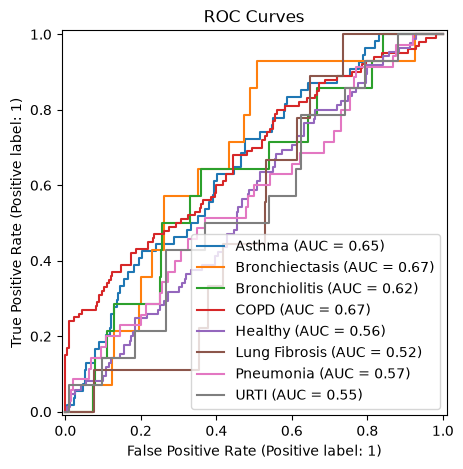

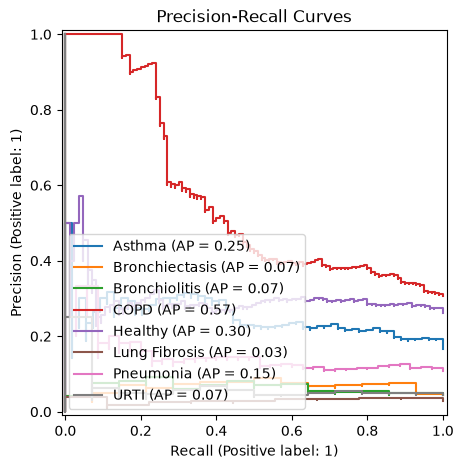

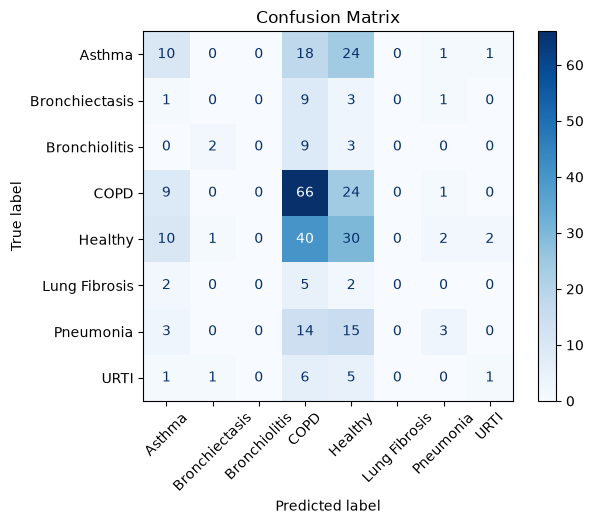

In [17]:
evaluate_model(model)

### ImagSTFT and RealSTFT
The combination is a stack of ImagSTFT and RealSTFT features, resulting in a 3-channel feature.

In [18]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-Stack_ImagSTFT_RealSTFT"
hparams["dataset"]["feature_extractor"] = ["ImagSTFT", "RealSTFT"]
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': ['ImagSTFT', 'RealSTFT'],
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-Stack_ImagSTFT_RealSTFT',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'resnet50', 'pretrained': None},
 'momentum': None,
 'num_workers': 2,
 'optimizer': 'AdamW

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 513, 108]        6,272
│    └─BatchNorm2d: 2-2                       [16, 64, 513, 108]        128
│    └─ReLU: 2-3                              [16, 64, 513, 108]        --
│    └─MaxPool2d: 2-4                         [16, 64, 257, 54]         --
│    └─Sequential: 2-5                        [16, 256, 257, 54]        --
│    │    └─Bottleneck: 3-1                   [16, 256, 257, 54]        75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 257, 54]        70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 257, 54]        70,400
│    └─Sequential: 2-6                        [16, 512, 129, 27]        --
│    │    └─Bottleneck: 3-4                   [16, 512, 129, 27]        379,392

c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | train | 0    
1  | criterion         | CrossEntropyLoss  | 0      | train | 0    
2  | train_f1_macro    | MulticlassF1Score | 0      | train | 0    
3  | train_f1_micro    | MulticlassF1Score | 0      | train | 0    
4  | train_f1_weighted | MulticlassF1Score | 0      | train | 0    
5  | val_f1_macro      | MulticlassF1Score | 0      | train | 0    
6  | val_f1_micro      | MulticlassF1Score | 0      | train | 0    
7  | val_f1_weighted   | MulticlassF1Score | 0      | train | 0    
8  | test_f1_macro     | MulticlassF1Score | 0      | train | 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 15, global step 2432: 'val_f1_macro' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.372. Signaling Trainer to stop.
Epoch 16, global step 2584: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1         0.38333332538604736
 test_Bronchiectasis_f1            0.625
  test_Bronchiolitis_f1     0.11764705926179886
      test_COPD_f1          0.8127853870391846
     test_Healthy_f1        0.31168830394744873
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1       0.8799999952316284
      test_URTI_f1                 0.25
      test_f1_macro         0.4225567579269409
      test_f1_micro          0.563076913356781
    test_f1_weighted        0.5328279733657837
        test_loss            1.457355260848999
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_Sofia\IA901_P

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.35      0.43      0.38        54
Bronchiectasis       0.56      0.71      0.62        14
 Bronchiolitis       0.33      0.07      0.12        14
          COPD       0.75      0.89      0.81       100
       Healthy       0.35      0.28      0.31        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.82      0.94      0.88        35
          URTI       0.30      0.21      0.25        14

      accuracy                           0.56       325
     macro avg       0.43      0.44      0.42       325
  weighted avg       0.52      0.56      0.53       325



c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

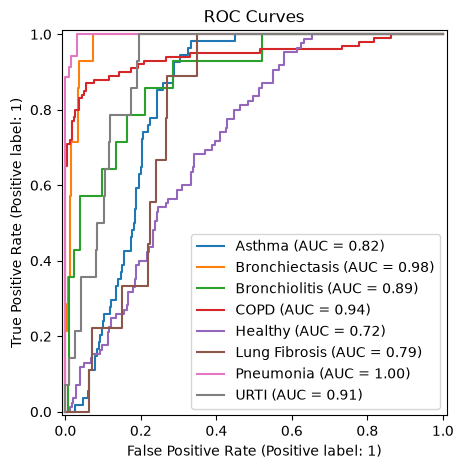

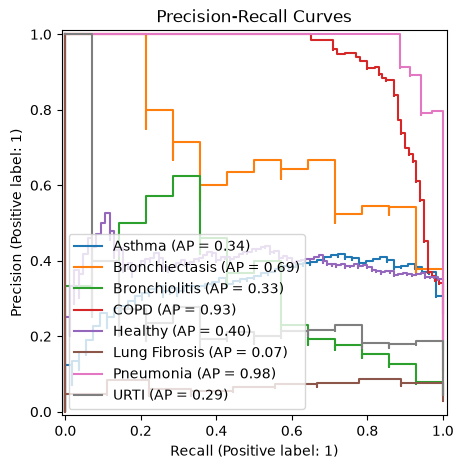

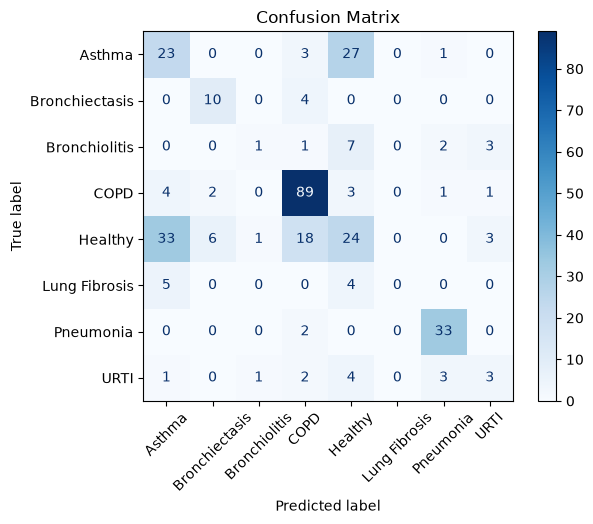

In [19]:
evaluate_model(model)

### MagSTFT and Phase
The combination is a stack of MagSTFT and Phase features, resulting in a 3-channel feature.

In [20]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-Stack_MagSTFT_Phase"
hparams["dataset"]["feature_extractor"] = ["MagSTFT", "Phase"]
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': ['MagSTFT', 'Phase'],
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-Stack_MagSTFT_Phase',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'resnet50', 'pretrained': None},
 'momentum': None,
 'num_workers': 2,
 'optimizer': 'AdamW',
 'pat

Using 16bit Automatic Mixed Precision (AMP)


Model Summary:

Input shape: (16, 2, 1025, 216)
Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 513, 108]        6,272
│    └─BatchNorm2d: 2-2                       [16, 64, 513, 108]        128
│    └─ReLU: 2-3                              [16, 64, 513, 108]        --
│    └─MaxPool2d: 2-4                         [16, 64, 257, 54]         --
│    └─Sequential: 2-5                        [16, 256, 257, 54]        --
│    │    └─Bottleneck: 3-1                   [16, 256, 257, 54]        75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 257, 54]        70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 257, 54]        70,400
│    └─Sequential: 2-6                        [16, 512, 129, 27]        --
│    │    └─Bottleneck: 3-4    

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | trai

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 16, global step 2584: 'val_f1_macro' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.379. Signaling Trainer to stop.
Epoch 17, global step 2736: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1         0.3232323229312897
 test_Bronchiectasis_f1             1.0
  test_Bronchiolitis_f1     0.3636363744735718
      test_COPD_f1          0.9047619104385376
     test_Healthy_f1        0.6436781883239746
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1       0.7594936490058899
      test_URTI_f1          0.27586206793785095
      test_f1_macro         0.5338330864906311
      test_f1_micro         0.6738461256027222
    test_f1_weighted        0.6528573036193848
        test_loss           1.1850357055664062
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_Sofia\IA9

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.36      0.30      0.32        54
Bronchiectasis       1.00      1.00      1.00        14
 Bronchiolitis       0.50      0.29      0.36        14
          COPD       0.86      0.95      0.90       100
       Healthy       0.63      0.66      0.64        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.68      0.86      0.76        35
          URTI       0.27      0.29      0.28        14

      accuracy                           0.67       325
     macro avg       0.54      0.54      0.53       325
  weighted avg       0.64      0.67      0.65       325



c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

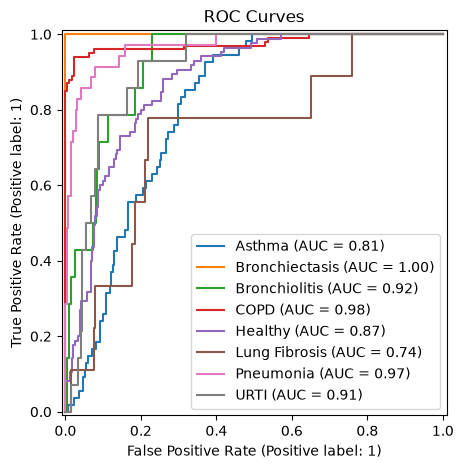

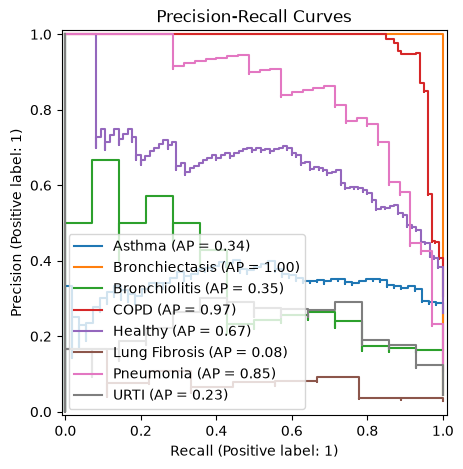

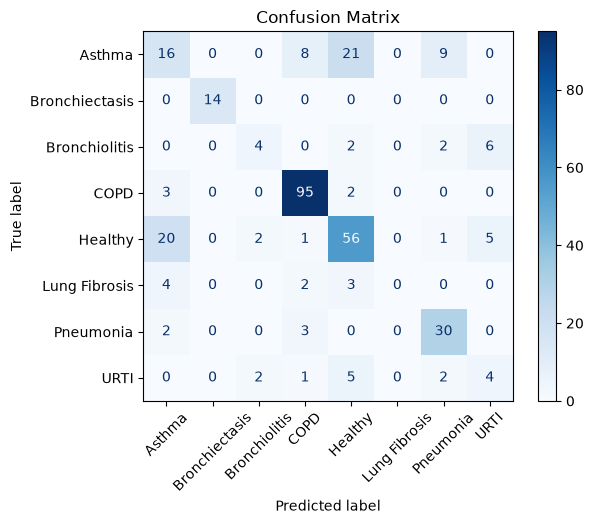

In [21]:
evaluate_model(model)

### MelSpectrogram, MFCC and Chroma
The combination is a stack of MelSpectrogram, MFCC and Chroma features, resulting in a 3-channel feature.

In [22]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-Stack_MelSpectrogram_MFCC_Chroma"
hparams["dataset"]["feature_extractor"] = ["MelSpectrogram", "MFCC", "Chroma"]
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': ['MelSpectrogram', 'MFCC', 'Chroma'],
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-Stack_MelSpectrogram_MFCC_Chroma',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False, 'name': 'resnet50', 'pretrained': None},
 'momentum': None,
 'num_workers': 2,

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Model Summary:

Input shape: (16, 3, 128, 216)
Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 64, 108]         9,408
│    └─BatchNorm2d: 2-2                       [16, 64, 64, 108]         128
│    └─ReLU: 2-3                              [16, 64, 64, 108]         --
│    └─MaxPool2d: 2-4                         [16, 64, 32, 54]          --
│    └─Sequential: 2-5                        [16, 256, 32, 54]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 32, 54]         75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 32, 54]         70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 32, 54]         70,400
│    └─Sequential: 2-6                        [16, 512, 16, 27]         --
│    │    └─Bottleneck: 3-4     

c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | train | 0    
1  | criterion         | CrossEntropyLoss  | 0      | train | 0    
2  | train_f1_macro    | MulticlassF1Score | 0      | train | 0    
3  | train_f1_micro    | MulticlassF1Score | 0      | train | 0    
4  | train_f1_weighted | MulticlassF1Score | 0      | train | 0    
5  | val_f1_macro      | Mul

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 19, global step 3040: 'val_f1_macro' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.262. Signaling Trainer to stop.
Epoch 20, global step 3192: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1         0.6352941393852234
 test_Bronchiectasis_f1     0.8799999952316284
  test_Bronchiolitis_f1     0.3636363744735718
      test_COPD_f1          0.8952381014823914
     test_Healthy_f1        0.7307692170143127
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1        0.699999988079071
      test_URTI_f1          0.4516128897666931
      test_f1_macro         0.5820688009262085
      test_f1_micro         0.7384615540504456
    test_f1_weighted         0.720549464225769
        test_loss           1.0571305751800537
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_Sof

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.87      0.50      0.64        54
Bronchiectasis       1.00      0.79      0.88        14
 Bronchiolitis       0.50      0.29      0.36        14
          COPD       0.85      0.94      0.90       100
       Healthy       0.62      0.89      0.73        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.84      0.60      0.70        35
          URTI       0.41      0.50      0.45        14

      accuracy                           0.74       325
     macro avg       0.64      0.56      0.58       325
  weighted avg       0.74      0.74      0.72       325



c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

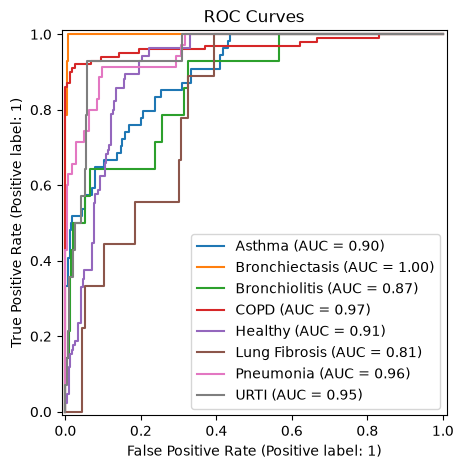

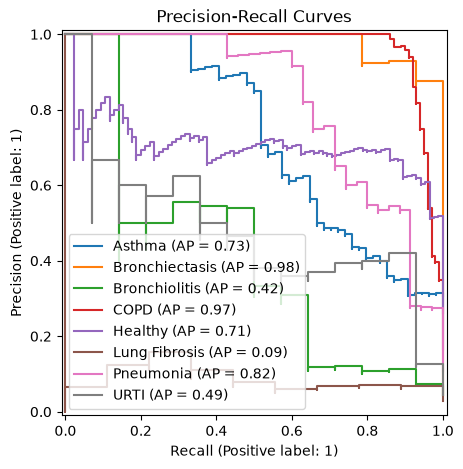

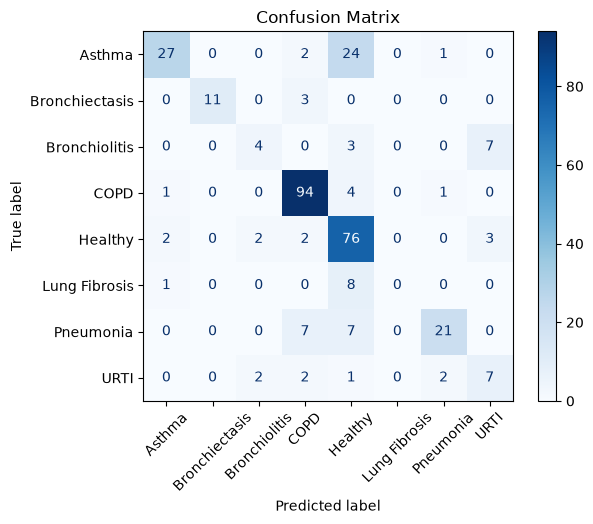

In [23]:
evaluate_model(model)

### MelSpectrogram, MFCC and Chroma with Pretrained Weights
The combination is a stack of MelSpectrogram, MFCC and Chroma features, resulting in a 3-channel feature, with imagenet pretrained weights (IMAGENET1K_V1).

In [24]:
hparams["experiment"] = "resnet50-classes=8-equalizer-sample_limit=1000-pretrained-Stack_MelSpectrogram_MFCC_Chroma"
hparams["dataset"]["feature_extractor"] = ["MelSpectrogram", "MFCC", "Chroma"]
hparams["model"]["pretrained"] = "IMAGENET1K_V1"
model = train_model(hparams)

Experiment hyperparameters:
{'batch_size': 16,
 'checkpoint_mode': 'max',
 'checkpoint_monitor': 'val_f1_macro',
 'criterion': 'CrossEntropyLoss',
 'dataset': {'classes': ['Asthma',
                         'Bronchiectasis',
                         'Bronchiolitis',
                         'COPD',
                         'Healthy',
                         'Lung Fibrosis',
                         'Pneumonia',
                         'URTI'],
             'feature_extractor': ['MelSpectrogram', 'MFCC', 'Chroma'],
             'name': 'Combined_ICBHI_KAUH',
             'sample_limit': 1000,
             'transforms': None},
 'early_stop_mode': 'max',
 'early_stop_monitor': 'val_f1_macro',
 'experiment': 'resnet50-classes=8-equalizer-sample_limit=1000-pretrained-Stack_MelSpectrogram_MFCC_Chroma',
 'gamma': 0.1,
 'learning_rate': 0.0001,
 'lr_scheduler': 'StepLR',
 'max_epochs': 100,
 'model': {'freeze_layers': False,
           'name': 'resnet50',
           'pretrained': 'IMAGENET1K

100%|██████████| 97.8M/97.8M [00:03<00:00, 34.1MB/s]
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Projeto_Sofia\IA901_Project\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Model Summary:

Input shape: (16, 3, 128, 216)
Layer (type:depth-idx)                        Output Shape              Param #
LungSoundClassifier                           [16, 8]                   --
├─ResNet: 1-1                                 [16, 8]                   --
│    └─Conv2d: 2-1                            [16, 64, 64, 108]         9,408
│    └─BatchNorm2d: 2-2                       [16, 64, 64, 108]         128
│    └─ReLU: 2-3                              [16, 64, 64, 108]         --
│    └─MaxPool2d: 2-4                         [16, 64, 32, 54]          --
│    └─Sequential: 2-5                        [16, 256, 32, 54]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 32, 54]         75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 32, 54]         70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 32, 54]         70,400
│    └─Sequential: 2-6                        [16, 512, 16, 27]         --
│    │    └─Bottleneck: 3-4     

c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

   | Name              | Type              | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0  | model             | ResNet            | 23.5 M | train | 0    
1  | criterion         | CrossEntropyLoss  | 0      | train | 0    
2  | train_f1_macro    | MulticlassF1Score | 0      | train | 0    
3  | train_f1_micro    | MulticlassF1Score | 0      | train | 0    
4  | train_f1_weighted | MulticlassF1Score | 0      | train | 0    
5  | val_f1_macro      | MulticlassF1Score | 0      | train | 0    
6  | val_f1_micro      | MulticlassF1Score | 0      | train | 0    
7  | val_f1_weighted   | MulticlassF1Score | 0      | train | 0    
8  | test_f1_macro     | MulticlassF1Score | 0      | train | 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 18, global step 2888: 'val_f1_macro' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_f1_macro did not improve in the last 10 records. Best score: 0.193. Signaling Trainer to stop.
Epoch 19, global step 3040: 'val_f1_macro' was not in top 1
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_Asthma_f1         0.6000000238418579
 test_Bronchiectasis_f1     0.3529411852359772
  test_Bronchiolitis_f1     0.4000000059604645
      test_COPD_f1           0.89952152967453
     test_Healthy_f1        0.6866952776908875
  test_Lung Fibrosis_f1             0.0
    test_Pneumonia_f1       0.3404255211353302
      test_URTI_f1          0.6000000238418579
      test_f1_macro         0.48494791984558105
      test_f1_micro         0.6861538290977478
    test_f1_weighted        0.6510071754455566
        test_loss            1.629340410232544
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test results saved to c:\Projeto_Sof

Classification Report:
                precision    recall  f1-score   support

        Asthma       0.92      0.44      0.60        54
Bronchiectasis       1.00      0.21      0.35        14
 Bronchiolitis       0.45      0.36      0.40        14
          COPD       0.86      0.94      0.90       100
       Healthy       0.54      0.94      0.69        85
 Lung Fibrosis       0.00      0.00      0.00         9
     Pneumonia       0.67      0.23      0.34        35
          URTI       0.56      0.64      0.60        14

      accuracy                           0.69       325
     macro avg       0.63      0.47      0.48       325
  weighted avg       0.72      0.69      0.65       325



c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Projeto_Sofia\IA901_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

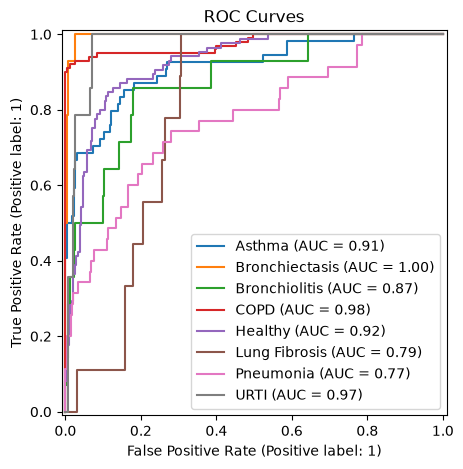

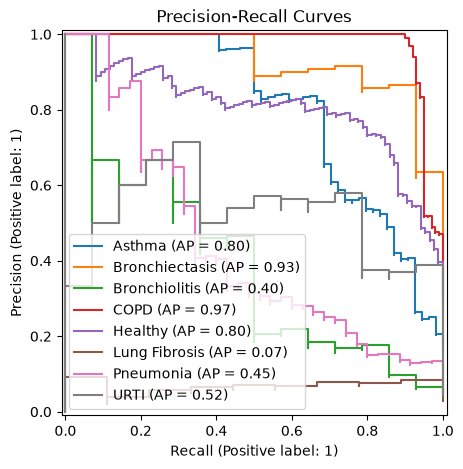

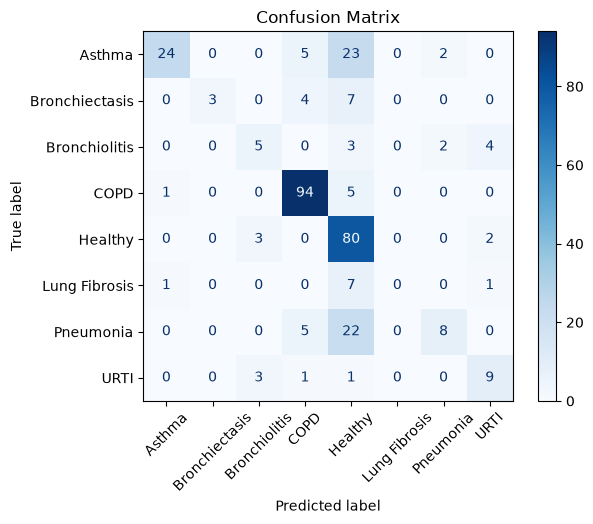

In [25]:
evaluate_model(model)

In [26]:
%tensorboard --logdir {LOGS_FOLDER}

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

PROJECT_ROOT = Path(r"C:\Projeto_Sofia\IA901_Project")

results_dir = PROJECT_ROOT / "assets" / "results" / "resnet50"
plots_dir = results_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

csv_files = sorted(results_dir.glob("*_results.csv"))

print(f"CSVs encontrados: {len(csv_files)}")

for csv_path in csv_files:
    df = pd.read_csv(csv_path)

    experiment_name = csv_path.stem.replace("_results", "")

    target = df["target"].to_numpy()
    pred = df["pred"].to_numpy()

    prob_cols = [col for col in df.columns if col.startswith("prob_")]
    class_names = [col.replace("prob_", "") for col in prob_cols]

    y_score = df[prob_cols].to_numpy()
    labels = list(range(len(class_names)))

   # =========================
# Confusion Matrix
# =========================
    cm = confusion_matrix(target, pred, labels=labels)

    fig, ax = plt.subplots(figsize=(10, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        xticks_rotation=45,
        colorbar=True,
        cmap="Blues",
        values_format="d"
    )

    ax.set_title(f"Confusion Matrix - {experiment_name}")

    plt.tight_layout()
    plt.savefig(
        plots_dir / f"{experiment_name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close(fig)

    # =========================
    # ROC Curves
    # =========================
    y_true_bin = label_binarize(target, classes=labels)

    fig, ax = plt.subplots(figsize=(9, 7))

    for i, class_name in enumerate(class_names):
        try:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")
        except ValueError:
            continue

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(f"ROC Curves - {experiment_name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(plots_dir / f"{experiment_name}_roc_curves.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

    # =========================
    # Precision-Recall Curves
    # =========================
    fig, ax = plt.subplots(figsize=(9, 7))

    for i, class_name in enumerate(class_names):
        try:
            precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
            ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
            ax.plot(recall, precision, label=f"{class_name} (AP = {ap:.2f})")
        except ValueError:
            continue

    ax.set_title(f"Precision-Recall Curves - {experiment_name}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(plots_dir / f"{experiment_name}_precision_recall_curves.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

print(f"Gráficos salvos em: {plots_dir}")

CSVs encontrados: 10
Gráficos salvos em: C:\Projeto_Sofia\IA901_Project\assets\results\resnet50\plots
